# Modelling 

## 1. Objective

This analysis examines the predictive value of the drone derived predictors against the response value of total biomass.

The objectives are to:

- assess the quality aof different model types;
- test the effect of linear and non linear models on the accuracy of prediction;
- identify potential modelling pitfalls in the data;
- obtain biomass allometric equations for documentation;
  

### Author: Elkana Kipruto

In [103]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
import io

In [7]:
inter_dir = '../../02_INTERMEDIATE'
merged_filepath = f'{inter_dir}/merged_acre_ecoplanet_parameters.gpkg'
if os.path.exists(merged_filepath):
    df = gpd.read_file(merged_filepath)
else:
    print('Invalid source path')

In [8]:
len(df)

217

## 2. Dataset

The analysis uses dataset version DV-004.
Other data versions including DV-005 (standardized for June 2026) have been tested on this same notebook before, and this is therefore the dataset chosen for modelling, 
The standardized dataset performed poorly, an indication that the model may have been modelling model inacurracies of the other model other than biomass signal.

The response variable is:

- `total_agb`: clump-level above-ground biomass (kg)

The dataset contains drone-derived canopy parameters and breast-height
structural parameters.
The predictor features tested in this notebook include:
- canopy_volume_m3
- canopy_area
- hmean
- hmedian


And additional breast height features including:
- breast_height_perimeter_m
- bh_outside_area_m2
- breast_height_valid_points


We know a few things from the exploratory data analysis we conducted:
* **Canopy volume is our single best predictor of biomass**
* **Canopy area has high correlation with canopy volume so we cannot fit both into same model**
* **Our data has a few high biomass clumps that could be outliers or exceptional plants - will affect modelling by either adding more info or more confusion**
* **Some of our features show linear relationship and other non linear with response variable. We will explore both, and in some cases explore both fitting linear and non linear relationship into the same model**
* **Breast height features appear to add more information to the model, albeit just modest**
* **Given the applicability of our model across various sites, we want a train test split that does not falsely inflate the accuracies by having same psp plants in both train and test. We train with some plants, and test with completely new unseen psp**
  a

In [9]:
df.columns

Index(['psp', 'year', 'date_of_collection', 'clump_id', 'total_culms',
       'total_agb', 'max_culm_diameter_cm', 'avg_culm_diameter_cm',
       'min_culm_diameter_cm', 'median_culm_diameter_cm', 'max_culm_agb',
       'avg_culm_agb', 'min_culm_agb', 'median_culm_agb', 'hmin', 'hmax',
       'hmean', 'hstd', 'hmedian', 'total_points', 'canopy_volume_m3',
       'gap_fraction', 'canopy_area', 'val_height', 'val_canopy_diameter',
       'breast_height_points', 'breast_height_valid_points',
       'breast_height_filtered_points', 'breast_height_cleaning_distance',
       'breast_height_area', 'breast_height_perimeter_m',
       'breast_height_diameter', 'bh_outside_area_m2', 'geometry'],
      dtype='str')

In [10]:
psps = df['psp'].unique()
for psp in psps:
    df_psp = df[df['psp']==psp]
    print(f'psp: {psp}, dates: {df_psp['date_of_collection'].unique()}')

psp: 1a-APM-01, dates: <StringArray>
['4/24/2025', '4/2/2026']
Length: 2, dtype: str
psp: 1a-APM-02, dates: <StringArray>
['4/25/2025', '5/3/2026']
Length: 2, dtype: str
psp: 1a-APM-07, dates: <StringArray>
['5/15/2025', '2/20/2026']
Length: 2, dtype: str
psp: 1a-APM-08, dates: <StringArray>
['5/15/2025', '2/24/2026']
Length: 2, dtype: str
psp: 1a-APM-13, dates: <StringArray>
['6/18/2025', '3/17/2026']
Length: 2, dtype: str
psp: 1a-GB-03, dates: <StringArray>
['5/20/2025', '6/3/2026']
Length: 2, dtype: str
psp: 1a-GB-05, dates: <StringArray>
['6/18/2025', '3/13/2026', '6/24/2026']
Length: 3, dtype: str


In [11]:
# df = df.drop(columns=['total_agb'])
# df.rename(columns={'total_agb_june_2026' : 'total_agb'}, inplace=True)

### Create the modelling dataset

In [96]:
# ---------------------------------------
# MODELLING DATA
# ---------------------------------------

model_df = df.copy()

# Keep 2026 only
model_df = model_df[model_df["year"] == 2026].copy()
model_df = model_df.loc[model_df['total_agb'] > 1]
#Target plot and date to remove
target_plot = '1a-GB-05'
target_date = '3/13/2026'

# Filter out the specific row using boolean indexing
model_df = model_df[~((model_df['psp'] == target_plot) & (model_df['date_of_collection'] == target_date))]

# Required columns
model_df = model_df[
    [
        "psp",
        "clump_id",
        "total_agb",
        "total_culms",
        "canopy_volume_m3",
        'canopy_area',
        'hmean',
        'hmedian',
        'breast_height_points', 'breast_height_valid_points',
        'breast_height_filtered_points', 'breast_height_cleaning_distance',
        'breast_height_area', 'breast_height_perimeter_m',
        'breast_height_diameter', 'bh_outside_area_m2'
    ]
].dropna()

print("Number of observations:", len(model_df))
print("Number of PSPs:", model_df["psp"].nunique())
print("PSPs:", model_df["psp"].unique())

Number of observations: 77
Number of PSPs: 7
PSPs: <StringArray>
['1a-APM-01', '1a-APM-02', '1a-APM-07', '1a-APM-08', '1a-APM-13',  '1a-GB-03',
  '1a-GB-05']
Length: 7, dtype: str


In [98]:
model_df.shape

(77, 16)

In [97]:
model_df.describe()

,total_agb,total_culms,canopy_volume_m3,canopy_area,hmean,hmedian,breast_height_points,breast_height_valid_points,breast_height_filtered_points,breast_height_cleaning_distance,breast_height_area,breast_height_perimeter_m,breast_height_diameter,bh_outside_area_m2
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,138.100000,36.038961,136.398312,23.024416,4.335455,4.429610,2125.571429,25582.974026,1320.532468,0.109351,13.563636,13.301169,3.825455,9.460779
std,110.076829,20.228589,105.022471,14.859603,1.141519,1.199863,1408.137931,16515.487782,827.344286,0.030922,9.945248,5.707600,1.634639,8.970529
min,1.310000,3.000000,1.870000,0.890000,1.490000,1.680000,153.000000,986.000000,153.000000,0.070000,0.520000,2.830000,0.810000,0.130000
25%,41.220000,19.000000,43.660000,10.970000,3.480000,3.550000,1149.000000,12144.000000,762.000000,0.090000,5.580000,9.420000,2.670000,2.880000
50%,123.010000,37.000000,121.170000,22.020000,4.500000,4.530000,1842.000000,24458.000000,1180.000000,0.090000,13.000000,13.690000,4.070000,8.350000
75%,211.210000,50.000000,214.260000,33.670000,5.080000,5.280000,2825.000000,37372.000000,1621.000000,0.130000,20.330000,17.270000,5.090000,12.990000
max,362.770000,82.000000,431.760000,59.840000,6.800000,7.390000,6763.000000,66516.000000,4050.000000,0.180000,47.630000,28.520000,7.790000,51.350000


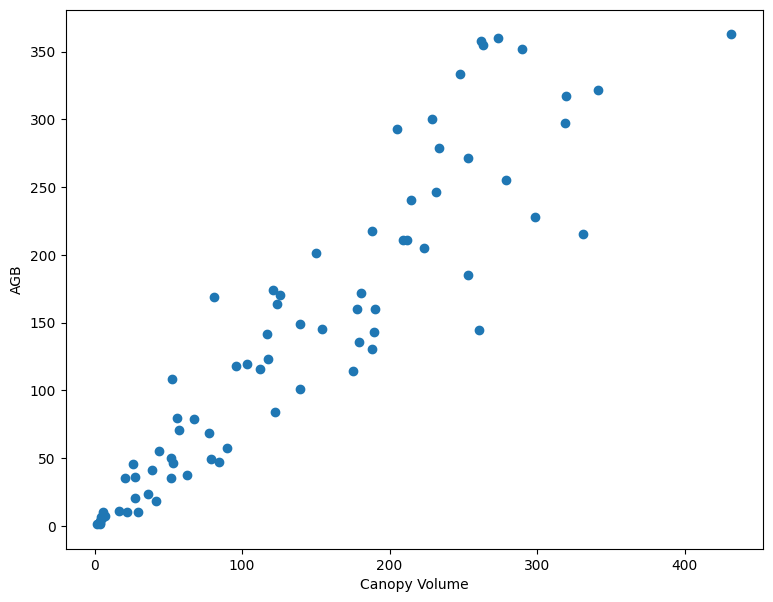

In [99]:
plt.figure(figsize=(9,7))
plt.scatter(x='canopy_volume_m3', y='total_agb', data=model_df)
plt.xlabel('Canopy Volume')
plt.ylabel('AGB')
plt.tight_layout
plt.show()

In [100]:
print(
    model_df["psp"]
    .value_counts()
    .sort_index()
)

psp
1a-APM-01    13
1a-APM-02    12
1a-APM-07    10
1a-APM-08    13
1a-APM-13     4
1a-GB-03     11
1a-GB-05     14
Name: count, dtype: int64


## 3. Group Fold splitting

Given the concept of spatial autocorrelation, and the evidence of site effect, we do not want to have plants that grow in the same plot appearing in both the training and testing samples. This will cause the model to overfit to certain psps, when in reality we want a model that can be taken from this psp into a new, completely unseen site. This is why we want to do a test that tests on a new, completely unseen psp

In [104]:
groups = model_df["psp"]

gkf = GroupKFold(n_splits=6)

In [105]:
fold_info = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(model_df, groups=model_df["psp"])
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    fold_info.append({
        "fold": fold,
        "test_psp": test["psp"].unique().tolist(),
        "n_train": len(train),
        "n_test": len(test),

        "train_agb_min": train["total_agb"].min(),
        "train_agb_max": train["total_agb"].max(),
        "train_agb_mean": train["total_agb"].mean(),

        "test_agb_min": test["total_agb"].min(),
        "test_agb_max": test["total_agb"].max(),
        "test_agb_mean": test["total_agb"].mean(),

        "test_agb_std": test["total_agb"].std()
    })

fold_info = pd.DataFrame(fold_info)

fold_info

,fold,test_psp,n_train,n_test,train_agb_min,train_agb_max,train_agb_mean,test_agb_min,test_agb_max,test_agb_mean,test_agb_std
0,0,[1a-GB-05],63,14,1.31,362.77,118.966190,21.01,359.82,224.202143,115.496522
1,1,[1a-APM-08],64,13,1.31,362.77,142.162500,1.43,292.78,118.100000,106.515184
2,2,[1a-APM-01],64,13,1.31,362.77,152.476094,7.63,211.12,67.325385,67.696264
3,3,[1a-APM-02],65,12,1.43,362.77,147.960769,1.31,215.70,84.687500,65.120883
4,4,[1a-GB-03],66,11,1.31,359.82,122.290606,10.00,362.77,232.956364,108.551808
5,5,"[1a-APM-07, 1a-APM-13]",63,14,1.31,362.77,144.890952,5.94,240.73,107.540714,74.140393


## 4. Model Evaluation

We create a common accuracy evaluation function to be shared by all models in this analysis

The accuracy metrics we use for evaluation:
- Mean Absolute Error (mae)
- Root Mean Square Error (rmse)
- Mean Bias Error (mbe)
- rRMSE

In [101]:
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    residuals = y_true - y_pred

    sse = np.sum(residuals ** 2)
    sst = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (sse / sst)

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))

    # Relative RMSE expressed as a percentage of mean observed biomass
    rrmse = 100 * rmse / np.mean(y_true)

    # Mean bias error
    mbe = np.mean(residuals)


    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "rRMSE_percent": rrmse,
        "MBE": mbe
    }

## 5. Baseline models

The first stage establishes baseline relationships between canopy structure and biomass.

The following model forms are evaluated:

* Null model using no predictors to be used as a baseline for other model evaluation
* Simple linear model using canopy volume.
* Multiple linear model using canopy area and mean height.
* Multiple linear model using canopy volume and mean height.
* Polynomial model using canopy volume.
* Power model using canopy volume.

These models provide a reference against which additional predictors and alternative model structures can be evaluated.

####  M0: Null model
* **Feature:** This model has no features. It predicts the mean biomass for each clump, therefore creating a baseline for which each model is judged.

In [ ]:
m0_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
    
    # Mean biomass from training PSPs only
    train_mean = train["total_agb"].mean()

    y_true = test["total_agb"]
    y_pred = np.full(
        len(test),
        train_mean
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M0_null"

    m0_predictions.append(fold_results)


m0_predictions = pd.concat(
    m0_predictions,
    ignore_index=True
)

##### Overall out of fold metrics

In [75]:
m0_metrics = calculate_metrics(
    m0_predictions["total_agb"],
    m0_predictions["prediction"]
)

print("M0: Null Model")
print("-" * 40)

for metric, value in m0_metrics.items():
    print(f"{metric}: {value:.4f}")

M0: Null Model
----------------------------------------
R2: -0.1506
MAE: 98.9797
RMSE: 117.3081
rRMSE_percent: 84.9443
MBE: -0.1471
Bias_percent: -687.2655
MAPE_percent: 723.3119


##### Per psp M0

In [102]:
m0_by_psp = []

for psp, group in m0_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m0_by_psp.append(metrics)


m0_by_psp = pd.DataFrame(m0_by_psp)

m0_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
]

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,-1.713994,97.190373,107.148988,159.150948
1,1a-APM-02,-1.029885,74.563141,88.830411,104.891998
2,1a-APM-07,-0.221237,63.069190,75.643650,67.122455
3,1a-APM-08,-0.055287,92.758654,105.127345,89.015533
4,1a-APM-13,-0.426388,91.635476,91.882151,97.070573
5,1a-GB-03,-1.143260,131.082231,151.522863,65.043453
6,1a-GB-05,-0.894077,129.871463,153.170606,68.318083


#### Predicting the total culms for use in prediction

In [77]:
model_df.columns

Index(['psp', 'clump_id', 'total_agb', 'total_culms', 'canopy_volume_m3',
       'canopy_area', 'hmean', 'hmedian', 'breast_height_points',
       'breast_height_valid_points', 'breast_height_filtered_points',
       'breast_height_cleaning_distance', 'breast_height_area',
       'breast_height_perimeter_m', 'breast_height_diameter',
       'bh_outside_area_m2'],
      dtype='str')

In [ ]:
# 1. Initialize standard KFold instead of GroupKFold
# Shuffle=True ensures random distribution of rows across folds
kf = KFold(n_splits=6, shuffle=True, random_state=42) 

m3_predictions_culms = []

# 2. Remove the groups argument from the split method
for train_idx, test_idx in kf.split(model_df):
    culms_df = model_df.copy()
    culms_df = culms_df.loc[culms_df['total_culms'] != 0]
    train = culms_df.iloc[train_idx] 
    test = culms_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------
    X_train = train[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_train = train["total_culms"]

    # -----------------------------
    # Test data
    # -----------------------------
    X_test = test[
        ['hmean', 'breast_height_perimeter_m', 'breast_height_valid_points']
    ]
    y_test = test["total_culms"]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['breast_height_perimeter_m'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on polynomial features
    # -----------------------------
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------
    y_pred = model.predict(X_test_poly)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp", "clump_id", "total_agb", 'total_culms',
            'breast_height_valid_points', 'breast_height_points',
            'breast_height_perimeter_m', 'breast_height_diameter',
            'breast_height_area', 'bh_outside_area_m2', 'hmean',
            'canopy_volume_m3', 'canopy_area'
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3_predictions_culms.append(fold_results)

m3_predictions_culms = pd.concat(
    m3_predictions_culms,
    ignore_index=True
)
m3_predictions_culms['prediction'] = round(m3_predictions_culms['prediction'])


In [79]:
m3_culms_metrics = calculate_metrics(
    m3_predictions_culms['total_culms'],
    m3_predictions_culms['prediction']
)
print("Culms prediction")
print('-'*41)
for metric, value in m3_culms_metrics.items():
    print(f'{metric}:{value:.4f}')

Culms prediction
-----------------------------------------
R2:0.6479
MAE:9.2727
RMSE:11.9251
rRMSE_percent:33.0894
MBE:0.1299
Bias_percent:-13.5352
MAPE_percent:36.2214


#### M1: Simple linear model

Evaluates whether canopy volume alone can explain biomass variations

Predictor:
* Canopy volume

Model form:
* `AGB=β0​+β1​Volume` 

In [ ]:
m1_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    X_train = train[
        ['canopy_volume_m3'
               ]
    ]

    y_train = train[
        "total_agb"
    ]

    X_test = test[
        ['canopy_volume_m3'
               ]
    ]

    y_test = test[
        "total_agb"
    ]

    model = LinearRegression()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    fold_results = test[
        ["psp", "clump_id", "total_agb"]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M1_linear"

    m1_predictions.append(
        fold_results
    )


m1_predictions = pd.concat(
    m1_predictions,
    ignore_index=True
)

In [82]:
m1_metrics = calculate_metrics(
    m1_predictions["total_agb"],
    m1_predictions["prediction"]
)

print("M1: Linear Regression")
print("-" * 40)

for metric, value in m1_metrics.items():
    print(f"{metric}: {value:.4f}")

M1: Linear Regression
----------------------------------------
R2: 0.8311
MAE: 32.4764
RMSE: 44.9457
rRMSE_percent: 32.5458
MBE: 1.2625
Bias_percent: -39.3335
MAPE_percent: 56.4914


##### Compare M0 and M1

In [84]:
results_m0_m1 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        }
    ]
)

results_m0_m1

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.150645,98.979661,117.308115,84.944326,-0.147112,-687.265459,723.311890
1,M1 - Linear Volume,0.831087,32.476369,44.945713,32.545773,1.262476,-39.333535,56.491441


#### What are the coefficients

In [85]:
model_m1_full = LinearRegression()

model_m1_full.fit(
    model_df[["canopy_volume_m3"]],
    model_df["total_agb"]
)

print(
    "Intercept:",
    model_m1_full.intercept_
)

print(
    "Volume coefficient:",
    model_m1_full.coef_[0]
)

Intercept: 6.403457578867744
Volume coefficient: 0.9655291241586365


#### Observed vs predicted

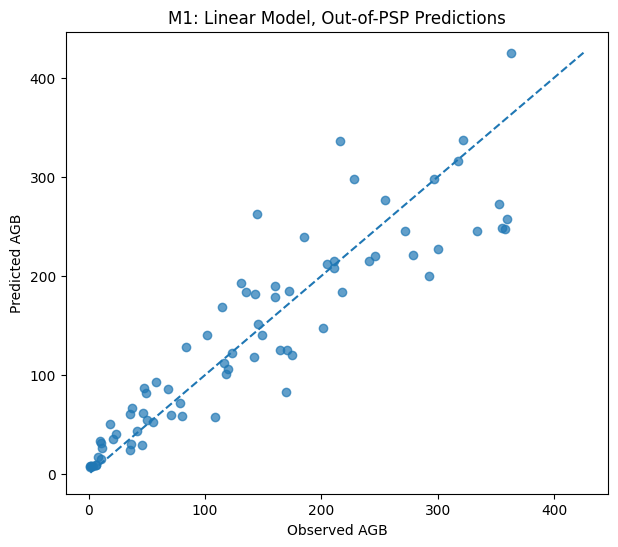

In [86]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["total_agb"],
    m1_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m1_predictions["total_agb"].min(),
    m1_predictions["prediction"].min()
)

max_val = max(
    m1_predictions["total_agb"].max(),
    m1_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title("M1: Linear Model, Out-of-PSP Predictions")

plt.show()

##### Residuals

In [87]:
m1_predictions["residual"] = (
    m1_predictions["total_agb"]
    - m1_predictions["prediction"]
)

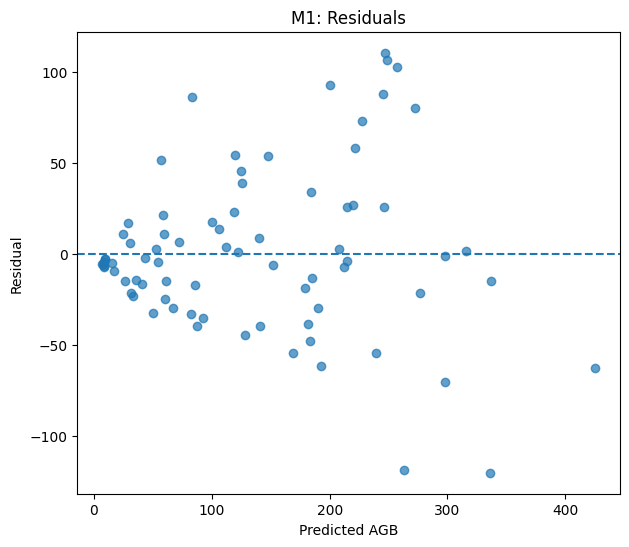

In [88]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m1_predictions["prediction"],
    m1_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M1: Residuals")

plt.show()

#### Per psp performance

In [89]:
m1_by_psp = []

for psp, group in m1_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m1_by_psp.append(metrics)

m1_by_psp = pd.DataFrame(m1_by_psp)

m1_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.651608,24.807130,38.389958,57.021520
1,1a-APM-02,0.469126,30.618522,45.427807,53.641691
2,1a-APM-07,0.740745,25.700435,34.852666,30.926542
3,1a-APM-08,0.884718,23.250287,34.746542,29.421289
4,1a-APM-13,0.662114,40.416309,44.719550,47.244784
5,1a-GB-03,0.832656,31.766713,42.339521,18.174872
6,1a-GB-05,0.676697,52.886308,63.282206,28.225514


#### M2: Multiple Linear Model Area + Height

The second model evaluates whether combining canopy area with mean canopy height provides additional information compared with canopy volume alone.

Predictors:

* canopy_area
* hmean

Model form:

    total_agb ~ canopy_area + hmean


In [114]:
m2_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
   
    X_train = train[
        [
             'hmean', 'canopy_area'
        ]
    ]   
    y_train = train["total_agb"]

    X_test = test[
        [
            'hmean', 'canopy_area'
        ]
    ]

    y_test = test["total_agb"]

    # Create model
    model = LinearRegression()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predict held-out PSP
    y_pred = model.predict(
        X_test
    )

    # Store out-of-fold predictions
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M2_area_hmean"

    m2_predictions.append(
        fold_results
    )


m2_predictions = pd.concat(
    m2_predictions,
    ignore_index=True
)

In [115]:
m2_predictions['prediction'] = m2_predictions['prediction'].clip(lower=1)

In [116]:
m2_metrics = calculate_metrics(
    m2_predictions["total_agb"],
    m2_predictions["prediction"]
)

print("M2: Area + Mean Height")
print("-" * 40)

for metric, value in m2_metrics.items():
    print(f"{metric}: {value:.4f}")

M2: Area + Mean Height
----------------------------------------
R2: 0.8315
MAE: 32.1246
RMSE: 44.8890
rRMSE_percent: 32.5047
MBE: -2.0429


#### M2: Multiple Linear Model Canopy volume + Height

The second model evaluates whether combining canopy volume with mean canopy height provides additional information compared with canopy volume alone.

Predictors:

* canopy_volume
* hmean

Model form:

    total_agb ~ canopy_volume + hmean


In [ ]:
m2_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]
   
    X_train = train[
        [
             'hmean', 'canopy_volume_m3'
        ]
    ]   
    y_train = train["total_agb"]

    X_test = test[
        [
            'hmean', 'canopy_volume_m3'
        ]
    ]

    y_test = test["total_agb"]

    # Create model
    model = LinearRegression()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predict held-out PSP
    y_pred = model.predict(
        X_test
    )

    # Store out-of-fold predictions
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M2_volume_hmean"

    m2_predictions.append(
        fold_results
    )


m2_predictions = pd.concat(
    m2_predictions,
    ignore_index=True
)

In [126]:
m2_predictions['prediction'] = m2_predictions['prediction'].clip(lower=1)

In [127]:
m2_metrics = calculate_metrics(
    m2_predictions["total_agb"],
    m2_predictions["prediction"]
)

print("M2: Volume + Mean Height")
print("-" * 40)

for metric, value in m2_metrics.items():
    print(f"{metric}: {value:.4f}")

M2: Volume + Mean Height
----------------------------------------
R2: 0.8585
MAE: 28.7790
RMSE: 41.1334
rRMSE_percent: 29.7853
MBE: -0.1954


#### Finding:
* Note that canopy volume and height outperforms canopy area and height, and so we take this as our best multiple linear model

##### M0 M1 M2 together

In [128]:
results_m0_m2 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        }
    ]
)

results_m0_m2

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.150645,98.979661,117.308115,84.944326,-0.147112,-687.265459,723.311890
1,M1 - Linear Volume,0.831087,32.476369,44.945713,32.545773,1.262476,-39.333535,56.491441
2,M2 - Area + Mean Height,0.858526,28.779026,41.133448,29.785263,-0.195398,NaN,NaN


##### M2 performance per psp

In [130]:
m2_by_psp = []

for psp, group in m2_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m2_by_psp.append(metrics)


m2_by_psp = pd.DataFrame(
    m2_by_psp
)

m2_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.643264,25.832735,38.846943,57.700291
1,1a-APM-02,0.498617,29.514600,44.147992,52.130470
2,1a-APM-07,0.834611,20.231631,27.837202,24.701364
3,1a-APM-08,0.946840,15.013834,23.595078,19.978898
4,1a-APM-13,0.880605,24.027314,26.583099,28.084200
5,1a-GB-03,0.856089,27.841296,39.263397,16.854400
6,1a-GB-05,0.697235,51.866044,61.239200,27.314280


##### Observed vs predicted

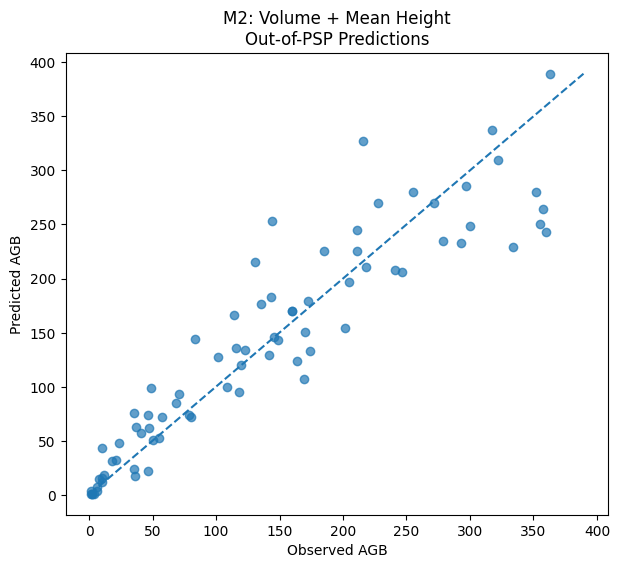

In [132]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2_predictions["total_agb"],
    m2_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m2_predictions["total_agb"].min(),
    m2_predictions["prediction"].min()
)

max_val = max(
    m2_predictions["total_agb"].max(),
    m2_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M2: Volume + Mean Height\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [58]:
m2_predictions["residual"] = (
    m2_predictions["total_agb"]
    - m2_predictions["prediction"]
)

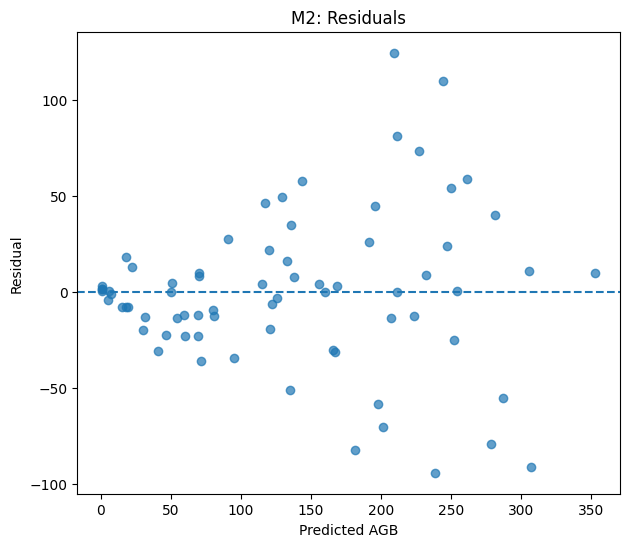

In [59]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m2_predictions["prediction"],
    m2_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")
plt.title("M2: Residuals")

plt.show()

#### Intercept

In [135]:
# Fit M2 on all 2026 data for interpretation only

m2_full = LinearRegression()

m2_full.fit(
    model_df[
        [
            "canopy_volume_m3",
            "hmean"
        ]
    ],
    model_df["total_agb"]
)

print(
    "Intercept:",
    m2_full.intercept_
)

print(
    "Canopy volume coefficient:",
    m2_full.coef_[0]
)

print(
    "Mean height coefficient:",
    m2_full.coef_[1]
)

Intercept: -76.27347853836011
Canopy volume coefficient: 0.7314155722766227
Mean height coefficient: 26.43543557790257


#### M3A: Polynomial Model: Canopy Volume

A polynomial relationship is evaluated to determine whether the relationship between canopy volume and biomass is better represented as nonlinear.
Note that the height predictor is retained as linear

Predictor:

- canopy_volume_m3
- mean height

Model form:

    AGB ~ Volume + Volume²

The polynomial degree and implementation are specified in the corresponding code.

In [150]:
m3_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        [ 'canopy_volume_m3', 'hmean'
         ]
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3', 'hmean'
         ]
    ]

    y_test = test[
        "total_agb"
    ]

    # -----------------------------
    # Create polynomial features
    # -----------------------------
    
    # Target only 'canopy_volume_m3' for degree 2 (no bias column needed)
    # Let 'remainder="passthrough"' keep all other features untouched
    poly_transformer = ColumnTransformer(
        transformers=[
            ('volume_poly', PolynomialFeatures(degree=2, include_bias=False), ['canopy_volume_m3'])
        ],
        remainder='passthrough' 
    )

    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # -----------------------------
    # Linear regression on
    # polynomial features
    # -----------------------------

    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test_poly
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M3_polynomial_volume"

    m3_predictions.append(
        fold_results
    )


m3_predictions = pd.concat(
    m3_predictions,
    ignore_index=True
)

In [151]:
m3_metrics = calculate_metrics(
    m3_predictions["total_agb"],
    m3_predictions["prediction"]
)

print("M3: Polynomial Volume")
print("-" * 40)

for metric, value in m3_metrics.items():
    print(f"{metric}: {value:.4f}")

M3: Polynomial Volume
----------------------------------------
R2: 0.8505
MAE: 30.9358
RMSE: 42.2782
rRMSE_percent: 30.6142
MBE: 0.7646


In [153]:
results_m0_m3 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Volume + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume",
            **m3_metrics
        }
    ]
)

results_m0_m3

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.150645,98.979661,117.308115,84.944326,-0.147112,-687.265459,723.311890
1,M1 - Linear Volume,0.831087,32.476369,44.945713,32.545773,1.262476,-39.333535,56.491441
2,M2 - Volume + Mean Height,0.858526,28.779026,41.133448,29.785263,-0.195398,NaN,NaN
3,M3 - Polynomial Volume,0.850542,30.935751,42.278184,30.614181,0.764639,NaN,NaN


In [154]:
print(
    "M3 vs M1"
)

print(
    "R² improvement:",
    m3_metrics["R2"] - m1_metrics["R2"]
)

print(
    "MAE improvement:",
    m1_metrics["MAE"] - m3_metrics["MAE"]
)

print(
    "RMSE improvement:",
    m1_metrics["RMSE"] - m3_metrics["RMSE"]
)

print(
    "rRMSE improvement:",
    m1_metrics["rRMSE_percent"] - m3_metrics["rRMSE_percent"]
)

M3 vs M1
R² improvement: 0.01945494627874278
MAE improvement: 1.54061791833308
RMSE improvement: 2.6675295459904405
rRMSE improvement: 1.9315927197613618


In [155]:
# Fit on the full dataset ONLY for examining coefficients

X = model_df[
    ["canopy_volume_m3"]
]

y = model_df[
    "total_agb"
]

poly_full = PolynomialFeatures(
    degree=1,
    include_bias=False
)

X_poly = poly_full.fit_transform(X)

m3_full = LinearRegression()

m3_full.fit(
    X_poly,
    y
)

print(
    "Features:",
    poly_full.get_feature_names_out(
        ["canopy_volume_m3"]
    )
)

print(
    "Coefficients:",
    m3_full.coef_
)

print(
    "Intercept:",
    m3_full.intercept_
)

Features: ['canopy_volume_m3']
Coefficients: [0.96552912]
Intercept: 6.403457578867744


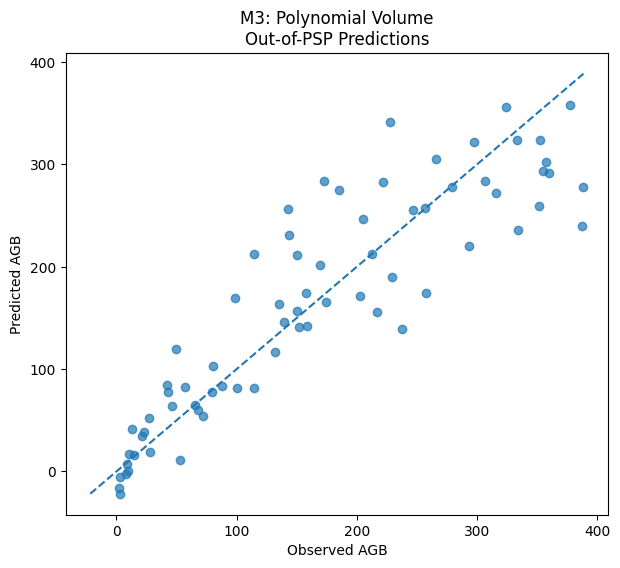

In [264]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3_predictions["total_agb"],
    m3_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m3_predictions["total_agb"].min(),
    m3_predictions["prediction"].min()
)

max_val = max(
    m3_predictions["total_agb"].max(),
    m3_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")

plt.title(
    "M3: Polynomial Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [265]:
m3_predictions["residual"] = (
    m3_predictions["total_agb"]
    - m3_predictions["prediction"]
)

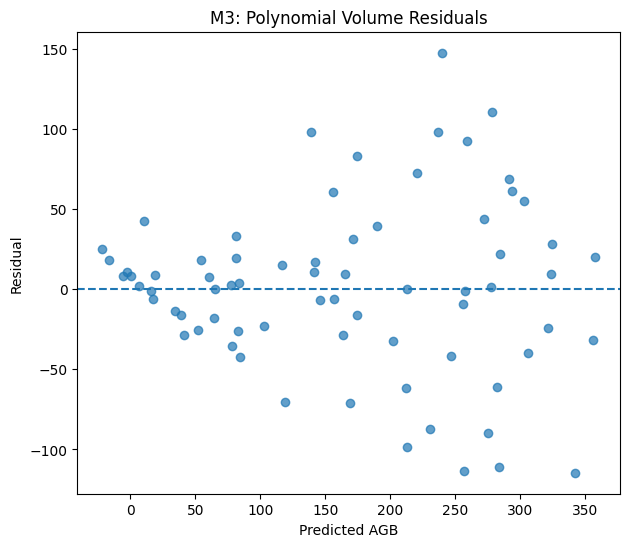

In [266]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m3_predictions["prediction"],
    m3_predictions["residual"],
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted AGB")
plt.ylabel("Residual")

plt.title(
    "M3: Polynomial Volume Residuals"
)

plt.show()

##### Per psp performance

In [267]:
m3_by_psp = []

for psp, group in m3_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m3_by_psp.append(metrics)


m3_by_psp = pd.DataFrame(
    m3_by_psp
)

m3_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.717889,27.491948,42.311392,48.537546
1,1a-APM-02,0.246301,42.347285,57.561553,57.929988
2,1a-APM-07,0.711651,40.343234,52.123884,34.826132
3,1a-APM-08,0.746222,53.330296,68.947087,37.688923
4,1a-APM-13,0.961111,13.854533,22.352339,18.317835
5,1a-GB-03,0.862355,30.716412,39.517635,16.292817
6,1a-GB-05,0.739270,46.999277,56.829316,25.347356


In [268]:
model_df[model_df['psp'] == '1a-APM-02'][['clump_id', 'canopy_volume_m3', 'total_agb', 'hmean']]

,clump_id,canopy_volume_m3,total_agb,hmean
16,CLUMP #10,117.73,135.01,4.56
17,CLUMP #11,96.00,131.97,3.74
18,CLUMP #13,188.14,142.99,5.60
20,CLUMP #15,331.43,227.18,5.74
21,CLUMP #2,3.27,2.67,2.73
23,CLUMP #4,67.53,87.50,3.74
25,CLUMP #6,62.36,42.78,3.48
26,CLUMP #7,35.89,26.68,3.68
27,CLUMP #8,39.13,46.42,3.93
28,CLUMP #9,179.01,150.44,4.45


#### M4: Normal Logarithm Power model

In [269]:
print("Minimum AGB:", model_df["total_agb"].min())
print("Minimum volume:", model_df["canopy_volume_m3"].min())

Minimum AGB: 2.06
Minimum volume: 1.87


In [270]:
from sklearn.preprocessing import FunctionTransformer

# ---------------------------------------
# M4: POWER MODEL
# log(AGB) ~ log(Features)
# ---------------------------------------

m4_predictions = []

# List all 5 features to maintain consistency with M3
features_to_use = [
   'canopy_volume_m3'
]

# Custom function to safely handle any unexpected negative sensor artifacts
def safe_log1p(X):
    return np.log1p(np.clip(X, a_min=0, a_max=None))

for train_idx, test_idx in gkf.split(
    m3_predictions_culms,
    groups=groups
):
    train = m3_predictions_culms.iloc[train_idx]
    test = m3_predictions_culms.iloc[test_idx]

    # -----------------------------
    # Data splitting
    # -----------------------------
    X_train = train[features_to_use]
    X_test = test[features_to_use]
    
    # Target log transformation (safe from 0 values)
    y_train = np.log1p(train["total_agb"])
    
    # -----------------------------
    # Log transform features
    # -----------------------------
    log_transformer = ColumnTransformer(
        transformers=[
            ('log_transform', FunctionTransformer(safe_log1p), ['canopy_volume_m3'])
        ],
        remainder='passthrough'
    )

    # Use .values to ensure smooth evaluation with the custom function
    X_train_log = log_transformer.fit_transform(X_train)
    X_test_log = log_transformer.transform(X_test)

    # -----------------------------
    # Fit log-log linear model
    # -----------------------------
    model = LinearRegression()
    model.fit(
        X_train_log,
        y_train
    )

    # -----------------------------
    # Predict and transform back
    # -----------------------------
    log_pred = model.predict(X_test_log)
    
    # Convert predictions back to original AGB scale safely
    y_pred = np.expm1(log_pred)

    # -----------------------------
    # Store predictions
    # -----------------------------
    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M4_power_volume_mean_height"

    m4_predictions.append(fold_results)

m4_predictions = pd.concat(
    m4_predictions,
    ignore_index=True
)

In [271]:
m4_metrics = calculate_metrics(
    m4_predictions["total_agb"],
    m4_predictions["prediction"]
)

print("M4: Power Volume")
print("-" * 40)

for metric, value in m4_metrics.items():
    print(f"{metric}: {value:.4f}")

M4: Power Volume
----------------------------------------
R2: 0.7813
MAE: 40.9534
RMSE: 55.6261
rRMSE_percent: 33.7734
MBE: 4.9984
Bias_percent: -7.3306
MAPE_percent: 32.0904


In [272]:
results_m0_m4 = pd.DataFrame(
    [
        {
            "Model": "M0 - Null",
            **m0_metrics
        },
        {
            "Model": "M1 - Linear Volume",
            **m1_metrics
        },
        {
            "Model": "M2 - Area + Mean Height",
            **m2_metrics
        },
        {
            "Model": "M3 - Polynomial Volume",
            **m3_metrics
        },
        {
            "Model": "M4 - Power Volume",
            **m4_metrics
        }
    ]
)

results_m0_m4

,Model,R2,MAE,RMSE,rRMSE_percent,MBE,Bias_percent,MAPE_percent
0,M0 - Null,-0.106056,107.600432,125.098526,75.953570,0.470506,-457.486436,492.852356
1,M1 - Linear Volume,0.778338,42.887904,56.002786,34.002092,-0.694019,-46.448703,63.780683
2,M2 - Area + Mean Height,0.799981,39.590684,53.198512,32.299477,0.048525,-19.640416,41.247854
3,M3 - Polynomial Volume,0.805143,38.794185,52.507512,31.879936,0.724180,17.447581,62.547418
4,M4 - Power Volume,0.781309,40.953417,55.626147,33.773416,4.998413,-7.330645,32.090375


In [273]:
# ---------------------------------------
# Full-data power model
# Interpretation only
# ---------------------------------------

X_full = np.log(
    model_df[["canopy_volume_m3"]]
)

y_full = np.log(
    model_df["total_agb"]
)

power_full = LinearRegression()

power_full.fit(
    X_full,
    y_full
)

alpha = power_full.intercept_
b = power_full.coef_[0]

a = np.exp(alpha)

print("a =", a)
print("b =", b)

print(
    f"AGB = {a:.4f} × Volume^{b:.4f}"
)

a = 1.0492867781286581
b = 1.0074715642561538
AGB = 1.0493 × Volume^1.0075


### Weighted Power Model

In [274]:
# ---------------------------------------
# MW4: WEIGHTED POWER / LOG-LOG MODEL
# ---------------------------------------

weighted_power_predictions = []

features_to_use = [
    "canopy_volume_m3", 'hmean'
]

target_col = "total_agb"

# Feature columns that will be log-transformed
log_features = features_to_use

# Column used to calculate the observation weights.
# This is the closest equivalent to the paper's log(D)-based weighting.
weight_feature = "canopy_volume_m3"

In [275]:
def safe_log(X, columns=None):
    """
    Apply natural logarithm while checking for invalid values.

    Parameters
    ----------
    X : pandas DataFrame or numpy array
        Input values.
    columns : list, optional
        Column names used for clearer error reporting.

    Returns
    -------
    numpy.ndarray
        Log-transformed values.
    """

    X_array = np.asarray(X, dtype=float)

    if np.any(~np.isfinite(X_array)):
        raise ValueError("Input contains NaN or infinite values.")

    if np.any(X_array <= 0):
        invalid_count = np.sum(X_array <= 0)

        raise ValueError(
            f"Log transformation encountered {invalid_count} "
            "zero or negative values."
        )

    return np.log(X_array)

In [276]:
check_cols = features_to_use + [target_col]

print(
    m3_predictions_culms[check_cols]
    .describe()
    .T
)

print("\nNon-positive values:")
print(
    (m3_predictions_culms[check_cols] <= 0)
    .sum()
)

                  count        mean         std   min     25%     50%  \
canopy_volume_m3   71.0  145.582676  103.941587  1.87  52.375  125.98   
hmean              71.0    4.405915    1.106436  1.49   3.700    4.50   
total_agb          71.0  164.703944  119.796400  2.06  55.175  150.52   

                      75%     max  
canopy_volume_m3  226.070  431.76  
hmean               5.085    6.80  
total_agb         256.840  388.43  

Non-positive values:
canopy_volume_m3    0
hmean               0
total_agb           0
dtype: int64


In [277]:
# ---------------------------------------
# GroupKFold by PSP
# ---------------------------------------

gkf = GroupKFold(n_splits=5)

for fold_number, (train_idx, test_idx) in enumerate(
    gkf.split(
        m3_predictions_culms,
        groups=groups
    ),
    start=1
):

    train = m3_predictions_culms.iloc[train_idx].copy()
    test = m3_predictions_culms.iloc[test_idx].copy()

    # ---------------------------------------
    # Data splitting
    # ---------------------------------------

    X_train = train[features_to_use].copy()
    X_test = test[features_to_use].copy()

    y_train = train[target_col].to_numpy(dtype=float)
    y_test = test[target_col].to_numpy(dtype=float)

    # ---------------------------------------
    # Log-transform predictors and target
    # ---------------------------------------

    X_train_log = safe_log(
        X_train,
        columns=log_features
    )

    X_test_log = safe_log(
        X_test,
        columns=log_features
    )

    y_train_log = safe_log(y_train)

    # ---------------------------------------
    # Calculate weights
    # ---------------------------------------
    # Paper:
    # weights = 1 / log(D)^2
    #
    # Here:
    # weights = 1 / log(canopy_volume_m3)^2
    #
    # Weights are calculated from training data only.
    # ---------------------------------------

    log_weight_variable = np.log(
        train[weight_feature].to_numpy(dtype=float)
    )

    if np.any(~np.isfinite(log_weight_variable)):
        raise ValueError(
            f"Invalid log values encountered in fold {fold_number}."
        )

    if np.any(np.isclose(log_weight_variable, 0)):
        raise ValueError(
            f"One or more weights are unstable in fold {fold_number}: "
            f"log({weight_feature}) is close to zero."
        )

    sample_weights = 1 / (log_weight_variable ** 2)

    # ---------------------------------------
    # Optional weight diagnostics
    # ---------------------------------------

    print(f"\nFold {fold_number} weight diagnostics")
    print("-" * 40)
    print(f"Minimum weight: {sample_weights.min():.6f}")
    print(f"Maximum weight: {sample_weights.max():.6f}")
    print(f"Median weight:  {np.median(sample_weights):.6f}")

    # ---------------------------------------
    # Fit weighted log-log linear model
    # ---------------------------------------

    model = LinearRegression()

    model.fit(
        X_train_log,
        y_train_log,
        sample_weight=sample_weights
    )

    # ---------------------------------------
    # Training residuals on log scale
    # ---------------------------------------

    train_log_pred = model.predict(X_train_log)
    train_log_residuals = y_train_log - train_log_pred

    n_train = len(y_train_log)
    n_parameters = X_train_log.shape[1] + 1  # predictors + intercept

    residual_degrees_of_freedom = n_train - n_parameters

    if residual_degrees_of_freedom <= 0:
        raise ValueError(
            f"Insufficient residual degrees of freedom in fold "
            f"{fold_number}."
        )

    # Weighted residual variance.
    #
    # This is the closest equivalent to the residual scale used
    # by weighted lm() in R.
    weighted_sse = np.sum(
        sample_weights * train_log_residuals ** 2
    )

    sigma_squared = (
        weighted_sse / residual_degrees_of_freedom
    )

    sigma = np.sqrt(sigma_squared)

    # ---------------------------------------
    # Lognormal retransformation correction
    # ---------------------------------------
    #
    # CF = exp(RSE^2 / 2)
    # ---------------------------------------

    correction_factor = np.exp(sigma_squared / 2)

    # ---------------------------------------
    # Predict on test data
    # ---------------------------------------

    test_log_pred = model.predict(X_test_log)

    # Standard log-log back-transformation:
    # exp(predicted log AGB)
    #
    # Bias-corrected:
    # exp(predicted log AGB) * CF
    # ---------------------------------------

    y_pred = np.exp(test_log_pred) * correction_factor

    # ---------------------------------------
    # Store predictions
    # ---------------------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            target_col
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["fold"] = fold_number
    fold_results["correction_factor"] = correction_factor
    fold_results["sigma_squared_log"] = sigma_squared
    fold_results["model"] = "MW4_weighted_power"

    weighted_power_predictions.append(fold_results)


Fold 1 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.041066

Fold 2 weight diagnostics
----------------------------------------
Minimum weight: 0.029403
Maximum weight: 2.552330
Median weight:  0.041079

Fold 3 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 0.712389
Median weight:  0.043649

Fold 4 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.043386

Fold 5 weight diagnostics
----------------------------------------
Minimum weight: 0.027160
Maximum weight: 2.552330
Median weight:  0.040446


In [278]:
weighted_power_predictions = pd.concat(
    weighted_power_predictions,
    ignore_index=True
)

weighted_power_metrics = calculate_metrics(
    weighted_power_predictions[target_col],
    weighted_power_predictions["prediction"]
)

print("\nMW4: Weighted Power Model")
print("-" * 40)

for metric, value in weighted_power_metrics.items():
    print(f"{metric}: {value:.4f}")


MW4: Weighted Power Model
----------------------------------------
R2: 0.7778
MAE: 39.5305
RMSE: 56.0733
rRMSE_percent: 34.0449
MBE: 3.5357
Bias_percent: -5.6739
MAPE_percent: 30.0936


##### Site specific

In [279]:
m4_by_psp = []

for psp, group in m4_predictions.groupby("psp"):

    metrics = calculate_metrics(
        group["total_agb"],
        group["prediction"]
    )

    metrics["psp"] = psp

    m4_by_psp.append(metrics)


m4_by_psp = pd.DataFrame(
    m4_by_psp
)

m4_by_psp[
    [
        "psp",
        "R2",
        "MAE",
        "RMSE",
        "rRMSE_percent"
    ]
].sort_values("psp")

,psp,R2,MAE,RMSE,rRMSE_percent
0,1a-APM-01,0.763962,23.450920,38.702422,44.397513
1,1a-APM-02,0.294925,35.374018,55.673835,56.030187
2,1a-APM-07,0.660731,45.256427,56.539177,37.776172
3,1a-APM-08,0.658396,60.649431,79.992724,43.726859
4,1a-APM-13,0.976388,12.889601,17.416985,14.273292
5,1a-GB-03,0.773794,41.157546,50.659669,20.886592
6,1a-GB-05,0.757102,49.557028,54.851507,24.465202


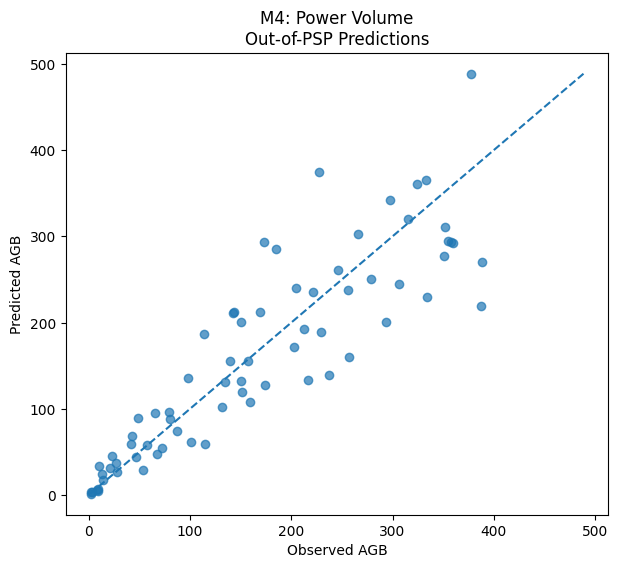

In [280]:
plt.figure(figsize=(7, 6))

plt.scatter(
    m4_predictions["total_agb"],
    m4_predictions["prediction"],
    alpha=0.7
)

min_val = min(
    m4_predictions["total_agb"].min(),
    m4_predictions["prediction"].min()
)

max_val = max(
    m4_predictions["total_agb"].max(),
    m4_predictions["prediction"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed AGB")
plt.ylabel("Predicted AGB")
plt.title(
    "M4: Power Volume\n"
    "Out-of-PSP Predictions"
)

plt.show()

##### Residuals

In [281]:
m4_predictions["residual"] = (
    m4_predictions["total_agb"]
    - m4_predictions["prediction"]
)

##### Biomass across levels

In [282]:
m4_predictions["biomass_bin"] = pd.qcut(
    m4_predictions["total_agb"],
    q=4,
    duplicates="drop"
)

m4_bias_by_bin = (
    m4_predictions
    .groupby(
        "biomass_bin",
        observed=True
    )
    .agg(
        observed_mean=("total_agb", "mean"),
        predicted_mean=("prediction", "mean"),
        mean_residual=("residual", "mean"),
        MAE=(
            "residual",
            lambda x: np.mean(np.abs(x))
        ),
        n=("residual", "size")
    )
)

m4_bias_by_bin

,observed_mean,predicted_mean,mean_residual,MAE,n
biomass_bin,,,,,
"(2.059, 55.175]",22.463889,29.637992,-7.174103,11.249815,18
"(55.175, 150.52]",107.257222,116.809137,-9.551915,31.566039,18
"(150.52, 256.84]",201.426471,204.583110,-3.156639,52.731870,17
"(256.84, 388.43]",329.708333,290.285084,39.423249,68.920302,18


#### M5: Random Forest

In [286]:
# ---------------------------------------
# M5: tree based
# ---------------------------------------

m5_predictions = []

for train_idx, test_idx in gkf.split(
    model_df,
    groups=groups
):

    train = model_df.iloc[train_idx]
    test = model_df.iloc[test_idx]

    # -----------------------------
    # Training data
    # -----------------------------

    X_train = train[
        ['canopy_volume_m3', 'hmean']
    ]

    y_train = train[
        "total_agb"
    ]

    # -----------------------------
    # Test data
    # -----------------------------

    X_test = test[
        ['canopy_volume_m3', 'hmean']
    ]

    y_test = test[
        "total_agb"
    ]


    # -----------------------------
    # Random forest regression
    # -----------------------------

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    # -----------------------------
    # Predict held-out PSP
    # -----------------------------

    y_pred = model.predict(
        X_test
    )

    # -----------------------------
    # Store predictions
    # -----------------------------

    fold_results = test[
        [
            "psp",
            "clump_id",
            "total_agb"
        ]
    ].copy()

    fold_results["prediction"] = y_pred
    fold_results["model"] = "M5_random_forest"

    m5_predictions.append(
        fold_results
    )


m5_predictions = pd.concat(
    m5_predictions,
    ignore_index=True
)

In [287]:
m5_metrics = calculate_metrics(
    m5_predictions["total_agb"],
    m5_predictions["prediction"]
)

print("M5: Random Forest")
print("-" * 40)

for metric, value in m5_metrics.items():
    print(f"{metric}: {value:.4f}")

M5: Random Forest
----------------------------------------
R2: 0.7318
MAE: 46.4277
RMSE: 61.6072
rRMSE_percent: 37.4048
MBE: 0.5655
Bias_percent: -36.9164
MAPE_percent: 57.4399
